In [1]:
import control as ct
import matplotlib.pyplot as plt
import math
import numpy as np
import cvxpy as cp
import networkx as ntx
from scipy.integrate import solve_ivp
import os

from control_utils.politopic_representation import *

rng = np.random.default_rng()

In [2]:
# constants
mi = 1.0 # damping coeficient
coupling_factor = 1.0
eps = 1e-9 #
eta = .9 # decay rate

# simulation time
time = 10

# normal cases
z_i_interval = [[0, 25]]
zeta_i_interval = []

# hyperplanes
a_i = np.array([
    [1, -1, 0, 0],
    [0, 0, 1, -1]
])
b_i = np.array([5, 5, 10, 10]).reshape(4, 1)+1
bR_i = np.array([5, 5, 10, 10]).reshape(4, 1)

# Connections Graph construction
N = 6

# Connections btw systems & Initial States
if N == 2:
    E_half = [(1, 2)] # N = 2
    x0 = np.array([2, 2, 3, -2, 0, 0, 0, 0]) # N = 2
elif N == 3:
    E_half = [(1, 2), (2, 3)] # N = 3
    x0 = np.array([2, 2, 3, -2, -2, -2, 0, 0, 0, 0, 0, 0]) # N = 3
elif N == 4:
    E_half = [(1, 2), (1, 3), (1, 4), (2, 3), (3, 4)]
    x0 = np.array([2, 2, 3, -2, -2, -2, -1, 2.5, 0, 0, 0, 0, 0, 0, 0, 0])
elif N==6:
    E_half = [(1, 2), (1, 3), (1, 4), (1, 6), (2, 3), (3, 4), (4, 5), (5, 6)]
    x0 = np.array([3, -6, 0, 0, -2, -2, -1, 2.5, -1, 0, 0, 1, 
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
else:
    pass

G = ntx.Graph()
G.add_nodes_from(range(1, N+1))
G.add_edges_from(E_half)

# for testing and comparison with the centralized
# # constants
# z_i_interval = [[0, 25], [0, 25]]
# zeta_i_interval = []

# # hyperplanes
# a_i = np.array([
#     [1, -1, 0, 0, 0, 0, 0, 0],
#     [0, 0, 1, -1, 0, 0, 0, 0],
#     [0, 0, 0, 0, 1, -1, 0, 0],
#     [0, 0, 0, 0, 0, 0, 1, -1]
# ])
# b_i = np.array([5, 5, 10, 10, 5, 5, 10, 10]).reshape(8, 1)+1
# bR_i = np.array([5, 5, 10, 10, 5, 5, 10, 10]).reshape(8, 1)

# # Connections Graph construction
# N = 1
# E_half = np.array([[1, 1]])

In [3]:
# kind of a constant in the way it is been built
a_cell = []
b_cell = []
bR_cell = []

for i in range(N):
    a_cell.append(a_i)
    b_cell.append(b_i)
    bR_cell.append(bR_i)

In [4]:
E_half = np.array(E_half)
if E_half.max() > N:
    raise Exception("Error in the connections set")

E_G = np.concat([E_half, np.flip(E_half, axis=1)], axis=0)
V_G = np.arange(start=1, stop=N+1)
A_G = np.zeros((N, N))
D_G = np.zeros((N, N))
L_G = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        is_in_array = np.any(np.all(E_G == [i+1, j+1], axis=1))

        if is_in_array:
            A_G[i, j] = 1

for i in range(N):
    D_G[i, i] = np.sum(A_G[i,:])

L_G = D_G- A_G

In [5]:
A_G

array([[0., 1., 1., 1., 0., 1.],
       [1., 0., 1., 0., 0., 0.],
       [1., 1., 0., 1., 0., 0.],
       [1., 0., 1., 0., 1., 0.],
       [0., 0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1., 0.]])

In [6]:
# generate combinations for multi-index -> j, k \in \mathbb{I}_{n_z} and l \in \mathbb{I}_{n_zeta}
n_z = len(z_i_interval)
n_zeta = len(zeta_i_interval)

interval_size = 2 # Just to make this information explict

amount_perm = 2*n_z + n_zeta
_, jkl_perm = permn(np.arange(interval_size), amount_perm) # TODO: handle n_zeta = 0

j_perm = jkl_perm[:, 0:n_z]
k_perm = jkl_perm[:, n_z:2*n_z]
l_perm = jkl_perm[:, 2*n_z:]

# check if every index is valid
# jkl_perm = jkl_perm[jkl_perm[:, 3] <= n_zeta]

In [7]:
jkl_perm

array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

In [8]:
def A_ijl(z: list[np.ndarray], **kwargs) -> np.ndarray:
    return np.array([
        [0, 1],
        [0, 0],
    ])

def C_ijl(z: list[np.ndarray], **kwargs) -> np.ndarray:
    return np.array([
        [1, 0]
    ]).reshape((1, 2))

C = np.array([
    [1, 0],
])

# for testing and comparison with the centralized
# def A_ijl(z: list[np.ndarray], **kwargs) -> np.ndarray:
#     return np.array([
#         [0, 1, 0, 0],
#         [0, 0, 0, 0],
#         [0, 0, 0, 1],
#         [0, 0, 0, 0]
#     ])

# def C_ijl(z: list[np.ndarray], **kwargs) -> np.ndarray:
#     return np.array([
#         [1, 0, 0, 0],
#         [0, 0, 1, 0]
#     ])


def phi_z(aj: np.ndarray, a: np.ndarray, b: np.ndarray):
    w = cp.Variable((a.shape[0], 1))

    constrains = []

    constrains += [ w >= 0]
    constrains += [ a.T@w == aj ]

    prob = cp.Problem(cp.Minimize(cp.trace(b.T@w)), constraints=constrains)
    result = prob.solve(solver=cp.MOSEK, verbose=False)

    return result

z_alpha_ij = lambda alpha_ij: np.array([
    [alpha_ij**2]
]).reshape((1, 1))

w0_alpha_ij = lambda j, alpha_ij: (z_i_interval[j][0] - z_alpha_ij(alpha_ij)) / (z_i_interval[j][1] - z_i_interval[j][0])
w1_alpha_ij = lambda j, alpha_ij: 1 - w0_alpha_ij(j, alpha_ij)

w_alpha_ij = lambda j, alpha_ij: [w0_alpha_ij(j, alpha_ij), w1_alpha_ij(j, alpha_ij)]

def W_ind(alpha: list[np.ndarray], J_perm_i): # TODO: maybe change alpha_i to list of np arrays
    '''
    alpha = [alpha_1, ..., alpha_N}], alpha_1 = [alpha_11, ..., alpha_1{n_{alpha_1}}]
    perm = multiindex permutations
    n_prods = number of products
    '''
    
    prod = 1

    for alpha_i in alpha: # same as N
        for k, alpha_ik in zip(range(alpha_i.shape[0]), alpha_i): # n_alpha_i
            prod *= w_alpha_ij(k, alpha_ik)[J_perm_i[k]]
            
    return prod

In [9]:
A_cell = []
C_cell = []

for i in range(N):
    A_i_cell = []
    C_i_cell = []

    for jkl in jkl_perm:
        z = []
        for j in range(n_z):
            z.append(z_i_interval[j][jkl[j]])
        A_i_cell.append(A_ijl(z))
        C_i_cell.append(C_ijl(z))
    
    A_cell.append(A_i_cell)
    C_cell.append(C_i_cell)

In [10]:
A_cell

[[array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]])],
 [array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]])],
 [array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]])],
 [array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]])],
 [array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]])],
 [array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]])]]

In [11]:
C_cell

[[array([[1, 0]]), array([[1, 0]]), array([[1, 0]]), array([[1, 0]])],
 [array([[1, 0]]), array([[1, 0]]), array([[1, 0]]), array([[1, 0]])],
 [array([[1, 0]]), array([[1, 0]]), array([[1, 0]]), array([[1, 0]])],
 [array([[1, 0]]), array([[1, 0]]), array([[1, 0]]), array([[1, 0]])],
 [array([[1, 0]]), array([[1, 0]]), array([[1, 0]]), array([[1, 0]])],
 [array([[1, 0]]), array([[1, 0]]), array([[1, 0]]), array([[1, 0]])]]

In [12]:
# # check observability
# Cobs = []
# rank = []
# for A in A_cell:
#     Cobs.append(ct.obsv(A, C))

# for Co in Cobs:
#     rank.append(np.linalg.matrix_rank(Co))

# if all(np.array(rank) == A_cell[0].shape[0]):
#     print("The quasi-LPV model is observable")
# else:
#     print("The quasi-LPV model is not observable")

In [13]:
nx = []
ny = []

for i in range(N):
    nx_i = A_cell[i][0].shape[0]
    ny_i = C_cell[i][0].shape[0]
    
    nx.append(nx_i)
    ny.append(ny_i)

P_trace = 0
P_cell = []
L_till_cell = []

for i in range(N): # TODO: MAYBE fix this L_till_cell having 16 elements instead of Perm(n_z) - quite possible actually as the Upsilon is actually l sums of jk
    P_i = cp.Variable((nx[i], nx[i]), symmetric=True)
    P_cell.append(P_i)

    L_till_i_cell = []
    for jkl in jkl_perm:
        L_till_ik = cp.Variable((nx[i], ny[i]))
        L_till_i_cell.append(L_till_ik)
    L_till_cell.append(L_till_i_cell)

constrains = []

for i in range(N):
    P_trace += cp.trace(P_cell[i])
    constrains += [P_cell[i] >> eps] # the same as P > 0

    Upsilon_jk_sum = 0
    for j in range(len(jkl_perm)):
        M = P_cell[i]@A_cell[i][j] - L_till_cell[i][j]@C_cell[i][j] + eta*P_cell[i]
        Upsilon_jk_sum += M + M.T

    constrains += [Upsilon_jk_sum << -eps]

    a_T = a_cell[i].T
    for j in range(a_T.shape[0]):
        aj = np.expand_dims(a_T[j], axis=1)
        phi = phi_z(aj, a_T, bR_cell[i])
        sj = 1/(b_cell[i][j] - phi) * aj

        M = cp.bmat([
            [np.eye(1), sj.T],
            [sj       , P_i],
        ])
        constrains += [ M >> 0 ] # >= breaks -> i know why but cannot remember right now

prob = cp.Problem(cp.Minimize(P_trace), constraints=constrains)
result = prob.solve(solver=cp.MOSEK, verbose=True)

                                     CVXPY                                     
                                     v1.6.0                                    
(CVXPY) Feb 23 02:11:20 PM: Your problem has 72 variables, 264 constraints, and 0 parameters.
(CVXPY) Feb 23 02:11:20 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 23 02:11:20 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 23 02:11:20 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 23 02:11:20 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 23 02:11:20 PM: Compiling problem (target solver=MOSEK).
(

In [14]:
is_positive_defined = []
for i in range(N):
    i_is_positive_defined = True if all(np.linalg.eig(P_cell[i].value).eigenvalues > 0) else False
print(f'e.g.: P[1] = \n{P_cell[0].value}')
print(f"The solution is \'{prob.status}\', with Trace(P) = {result:.2f} and P is {"Positive Defined" if all(is_positive_defined) else "NOT Positive Defined"}")

e.g.: P[1] = 
[[ 5.70612096e-09 -1.49119565e-09]
 [-1.49119565e-09  1.22196880e-09]]
The solution is 'optimal', with Trace(P) = 5.04 and P is Positive Defined


In [15]:
L_cell = []

for i in range(N):
    P_i_inv = np.linalg.inv(P_cell[i].value)

    L_till = []
    for j in range(len(L_till_cell[i])):
        # print(L_till_array[i].value)
        L_till.append(P_i_inv@L_till_cell[i][j].value)
    L_cell.append(L_till)

In [16]:
k = 0
A_cell[k], C_cell[k], L_cell[k]

([array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]]),
  array([[0, 1],
         [0, 0]])],
 [array([[1, 0]]), array([[1, 0]]), array([[1, 0]]), array([[1, 0]])],
 [array([[-64596946.28311116],
         [-97446847.42303191]]),
  array([[-64596837.78048524],
         [-97447285.2429626 ]]),
  array([[-64596999.65311702],
         [-97448119.55301644]]),
  array([[3.88308888e+08],
         [5.29717022e+08]])])

In [17]:
# simulação

def f_x(x_i, mi):
    return np.array([
        [x_i[1]],
        [-x_i[0] + mi*(1 - x_i[0]**2)*x_i[1]],
    ])

    return np.array([
        [x[1]],
        [-x[0] + mi*(1 - x[0]**2)*x[1]],
        [x[3]],
        [-x[2] + mi*(1 - x[2]**2)*x[3]]
    ])



def gd_x(x_i: np.ndarray, x_j_cell: list[np.ndarray], cp: float) -> np.ndarray[float]:
    gd = np.zeros(x_i.shape)

    for x_j in x_j_cell:
        gd[1] += -cp*math.tanh(x_j[1] - x_i[1])

    return gd.reshape((x_i.shape[0], 1))

    return np.array([
        [0],
        [-cp*math.tanh(x[3] - x[1])],
        [0],
        [-cp*math.tanh(x[1] - x[3])]
    ])

def gd_x_decoupled(x_i: np.ndarray, x_j_cell: list[np.ndarray], cp: float) -> np.ndarray[float]:
    gd = []

    for x_j in x_j_cell:
        gd_ij = -cp*math.tanh(x_j[1] - x_i[1])

        gd.append(gd_ij)

    return np.array(gd).reshape(len(gd), 1)

def h_x(x_i):
    return np.array([x_i[0]])

def g_ij(x_i, x_j):
    return np.array([
        [0],
        [-1]
    ]).reshape((2, 1))

def Gamma_inv(x_i: np.ndarray, y_i: np.ndarray, x_j_cell: list[np.ndarray]): # has the lie derivative varing for each

    Gamma = None
    for j in range(len(x_j_cell)): # columns
        Gamma_i = np.zeros(shape=(y_i.shape[0], 1))
        Gamma_i[0] = -1 # HARDCODED

        if Gamma is None:
            Gamma = Gamma_i
        else:
            Gamma = np.concat([Gamma, Gamma_i], axis=1)

    print(Gamma)

    return np.linalg.pinv(Gamma)

def Q_x(x_i: np.ndarray, y_i: np.ndarray, x_j_cell: list[np.ndarray], i: int, t: float):
    g_i = []
    for j in range(len(x_j_cell)):
        g_i.append(g_ij(x_i, x_j_cell[j]))
    g_i = np.array(g_i).T.squeeze().reshape((2, -1))

    G_i = Gamma_inv(x_i, y_i, x_j_cell)
    Q  = g_i@G_i

    # if t == 0.0:
    #     print(f"syst: {i+1} \ng = {g_i} \nGamma = \n{G_i} \nQ = \n{Q}\n\n")

    return Q

def Psi_x(x_i: np.ndarray, y_i: np.ndarray, x_j_cell: list[np.ndarray], mi: float):
    Psi = lambda x: -x[0] + mi*(1 - x[0]**2)*x[1]

    Psi_cell = []
    Psi_cell.append(Psi(x_i))

    for j in range(y_i.shape[0]-1):
        x_j = x_j_cell[j]
        Psi_cell.append(Psi(x_j))
    
    Psi_cell = np.array(Psi_cell).reshape((len(Psi_cell), 1))

    return Psi_cell

def Y_levants(xj_cell: list[list[np.ndarray, list[np.ndarray]]], cp: float):
    Y_l = []

    for xj in xj_cell:
        x_i = xj[0]
        x_j_cell = xj[1]

        Y_i = -x_i[0] + mi*(1 - x_i[0]**2)*x_i[1]
        for x_j in x_j_cell:
            Y_i += - cp*(math.tanh(x_j[1] - x_i[1]))
        Y_l.append(Y_i)
    Y_l = np.array(Y_l).reshape((len(xj_cell), 1))

    # for x_i in x_i_cell:
    #     Y_i = -x_i[0] + mi*(1 - x_i[0]**2)*x_i[1]
    #     for x_j in x_j_cell:
    #         Y_i += - cp*(math.tanh(x_j[2] - x_i[2]))
    #     Y_l.append(Y_i)
    # Y_l = np.array(Y_l).reshape((len(x_i_cell), 1))

    return Y_l

def L_alpha(alpha: list[np.ndarray], perms: np.ndarray, L_cell_i: list[np.ndarray]):
    L = 0

    for i in range(perms.shape[0]):
        L += W_ind(alpha, perms[i])*L_cell_i[i]

    return L

def model(t: float, x: np.ndarray[float], N: int, mi: float, cp: float, dist_hist: list[list]):

    # TODO: ADAPT THIS
    xdot = np.zeros(shape=x.shape) # half are the real states and the other half is the observer
    xdot = np.expand_dims(xdot, axis=1)

    nx = int(x.shape[0]/(2*N))

    x_i_cell = []
    x_hat_i_cell = []

    for i in range(N):
        id = i * nx
        id_hat = id + N*nx

        x_i_cell.append(x[id:id+nx])
        x_hat_i_cell.append(x[id_hat:id_hat+nx])

    dist_hist[0].append(t)
    for i in range(N):
        id = i * nx
        id_hat = id + N*nx

        x_i = x_i_cell[i]
        x_hat_i = x_hat_i_cell[i]
        x_j_cell = []

        alpha_i = [np.array([x_i[0]**2])]

        for a in range(A_G[i].shape[0]):
            if A_G[i][a] == 1:
                x_j_cell.append(x_i_cell[a])

        # missing levants differentiator
        d_i = gd_x(x_i, x_j_cell, cp) # g*d - coupling
        d_i_decoupled = gd_x_decoupled(x_i, x_j_cell, cp)

        #######
        xj_cell = [[x_i, x_j_cell]]

        xdot[id:id+nx] = f_x(x_i, mi) + d_i

        y_i = h_x(x_hat_i)
        Q = Q_x(x_hat_i, y_i, x_j_cell, i, t)
        Psi = Psi_x(x_hat_i, y_i, x_j_cell, mi)
        Y = Y_levants(xj_cell, cp)
        L = L_alpha(alpha_i, k_perm, L_cell[i])

        delta = np.expand_dims(C@x_i - y_i, axis=1)
        
        d_hat = (Y - Psi) # TODO: remove
        d_hat_decoupled = Gamma_inv(x_hat_i, y_i, x_j_cell)@(Y - Psi)
        xdot[id_hat:id_hat+nx] = f_x(x_hat_i, mi) + Q@(Y - Psi) + L@delta

        if len(dist_hist) < i + 2:
            dist_hist.append([[], []])

        # if i == 0 and t == 0:
        #     print(Gamma_inv(x_hat_i, y_i, x_j_cell))
        #     print(d_hat)
        #     print("***")
        #     print(d_i_decoupled)
        #     print(d_hat_decoupled)
        #     print("##########")
        
        dist_hist[i+1][0].append(d_i_decoupled)
        dist_hist[i+1][1].append(d_hat_decoupled)

    return xdot.flatten()

In [18]:
if x0.shape[0] != A_cell[0][0].shape[0]*2*N:
    raise Exception("error in X0 array")

sim_time = (0, time)
dist_hist = [[]]

result = solve_ivp(model, sim_time, x0, args=(N, mi, coupling_factor, dist_hist), method="BDF", dense_output=True)  # LSODA
t = result.t
x = result.y

[[-1. -1. -1. -1.]]
[[-1. -1. -1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1. -1. -1.]]
[[-1. -1. -1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1. -1. -1.]]
[[-1. -1. -1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1. -1. -1.]]
[[-1. -1. -1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1. -1. -1.]]
[[-1. -1. -1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1. -1. -1.]]
[[-1. -1. -1. -1.]]
[[-1. -1.]]
[[-1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1. -1.]]
[[-1. -1

In [19]:
for i in range(0, len(dist_hist)):
    dist_hist[i] = np.array(dist_hist[i])

In [20]:
def plot_graph(x, nx):
    plt.figure(dpi=150, constrained_layout=True)
    # plt.suptitle(f'{N}-Interconnected Oscilators', y=1.0)

    cols = 2
    rows = math.ceil(N/cols)

    for i in range(N):
        ind = i * nx
        ind_hat = ind + N*nx

        plt.subplot(rows, cols, i+1)
        plt.title(f"Oscilator {i+1}", fontsize=8)
        plt.scatter(x0[ind], x0[ind+1], s=30, facecolors='none', edgecolors='k') #, label=f'$\\mathbf{{x}}_{i+1}$')
        plt.plot(x[ind, :], x[ind+1, :], 'k') #, label=f'$\\mathbf{{x}}_{i+1}$')
        plt.plot(x[ind_hat, :], x[ind_hat+1, :], 'r--', linewidth=1) #, label=f'$\\mathbf{{\\hat{{x}}}}_{i+1}$')
        # plt.xlabel("$x_1$")
        # plt.ylabel("$x_2$")
        # plt.legend()
        
        plt.grid(which='both')
    
    legend = plt.figlegend([r'$\mathbf{x}_0$', r'$\mathbf{x}$', r'$\mathbf{\hat{x}}$'], loc = 'lower center', ncol = 3,  bbox_to_anchor=(0.5, -0.1))

    dir = os.path.join(os.curdir, f'.figures/')
    if not os.path.isdir(dir):
        os.mkdir(dir)

    plt.savefig(f".figures/dynamics_{N}", dpi=600, bbox_inches='tight', bbox_extra_artists=[legend])
    plt.show()

[]

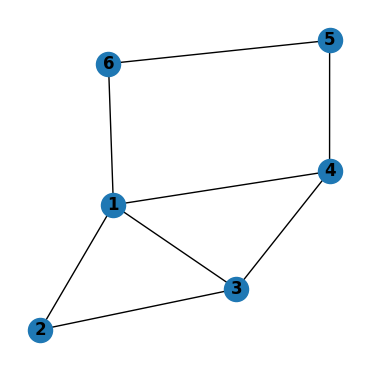

In [21]:
plt.figure(figsize=(3.5, 3.5), dpi=100)
ntx.draw(G, with_labels=True, font_weight='bold')
plt.savefig(f".figures/grafo_{N}", dpi=600)
plt.plot()

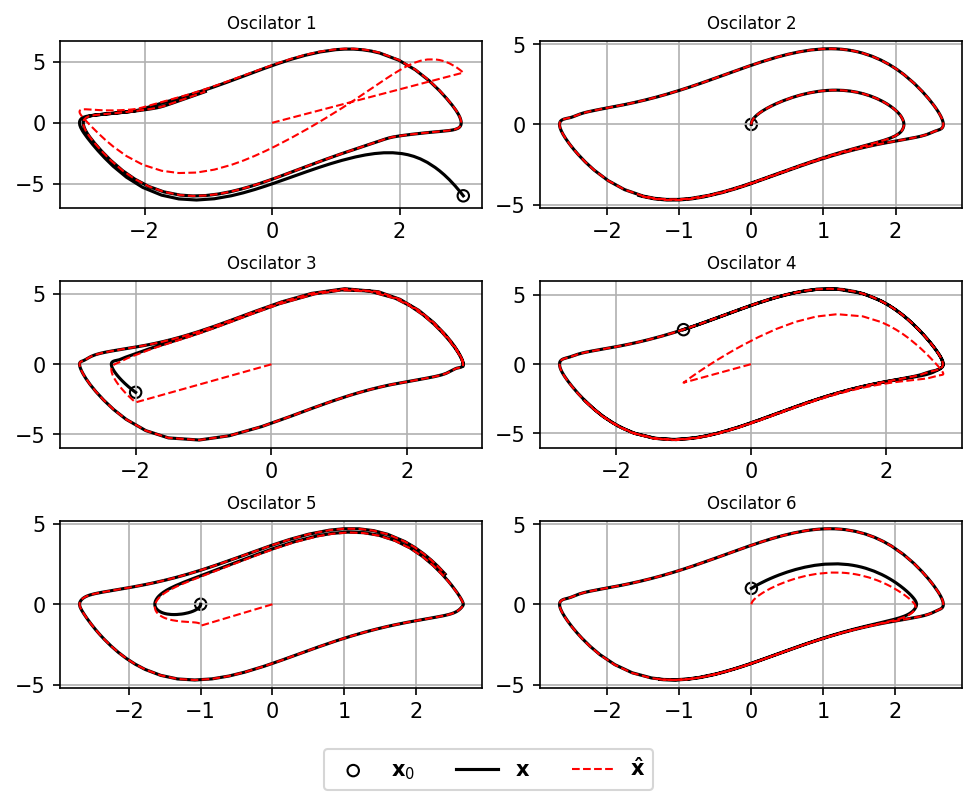

In [22]:
nx = A_cell[0][0].shape[0]
plot_graph(x, nx)

In [23]:
dist_hist[1][0, :, 0]

array([[-0.99998771],
       [-0.99998771],
       [-0.99998771],
       ...,
       [ 0.99999834],
       [ 0.99999831],
       [ 0.99999831]])

In [24]:
dist_hist[i][0, 0]

array([[0.99999834],
       [0.76159416]])

In [25]:
gg = np.array([
    [0, 0],
    [-1, -1]
])

In [26]:
np.linalg.pinv(gg)

array([[ 0. , -0.5],
       [ 0. , -0.5]])

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
C:\Users\luiza\AppData\Local\Temp\ipykernel_9380\244836371.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(dist_hist[0], -1*(dist_hist[i][1, :, 0] + dist_hist[i][1, :, 1] + dist_hist[i][1, :, 2] + dist_hist[i][1, :, 3]), label=f"$\hat{{d}}_{i}$")
C:\Users\luiza\AppData\Local\Temp\ipykernel_9380\244836371.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(dist_hist[0], -1*(dist_hist[i][1, :, 0] + dist_hist[i][1, :, 1] + dist_hist[i][1, :, 2] + dist_hist[i][1, :, 3]), label=f"$\hat{{d}}_{i}$")


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\luiza\\repos\\Control-Scripts\\notebooks\\unknown_input_observer\\figures\\dist_6.png'

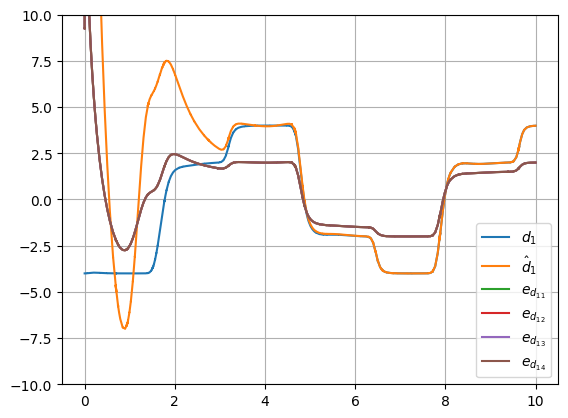

In [27]:
# for i in range(1, N+1):
for i in range(1, 1+1):
    plt.plot(dist_hist[0], dist_hist[i][0, :, 0] + dist_hist[i][0, :, 1] + dist_hist[i][0, :, 2] + dist_hist[i][0, :, 3], label=f"$d_{i}$")
    plt.plot(dist_hist[0], -1*(dist_hist[i][1, :, 0] + dist_hist[i][1, :, 1] + dist_hist[i][1, :, 2] + dist_hist[i][1, :, 3]), label=f"$\hat{{d}}_{i}$")
    plt.plot(dist_hist[0], dist_hist[i][0, :, 0] - dist_hist[i][1, :, 0], label=f'$e_{{d_{{{i}1}}}}$')
    plt.plot(dist_hist[0], dist_hist[i][0, :, 0] - dist_hist[i][1, :, 1], label=f'$e_{{d_{{{i}2}}}}$')
    plt.plot(dist_hist[0], dist_hist[i][0, :, 0] - dist_hist[i][1, :, 2], label=f'$e_{{d_{{{i}3}}}}$')
    plt.plot(dist_hist[0], dist_hist[i][0, :, 0] - dist_hist[i][1, :, 3], label=f'$e_{{d_{{{i}4}}}}$')

    # plt.plot(dist_hist[0], dist_hist[i][0, :, 0] - dist_hist[i][1, :, 0], label=f'$e_{{d_{i}}}$') # original comparison

plt.ylim([-10, 10])
# plt.xlim([-0.2, 4.2])
plt.legend()
plt.grid()
plt.savefig(f"figures/dist_{N}", dpi=600)
plt.show()